In [8]:
import json
import matplotlib.pyplot as plt
import numpy as np

def load(path):
    with open(path) as f:
        return json.load(f)

runs = {
    "1_base": load("../results/run_nodes1_base.json"),
    "1_opt": load("../results/run_nodes1_opt.json"),
    "3_base": load("../results/run_nodes3_base.json"),
    "3_opt": load("../results/run_nodes3_opt.json"),
}

## Time: 1 node vs 3 nodes

LIGHT — Time: 1 vs 3 nodes
x=array([0, 1, 2])
y1=[0.2769, 0.1865, 0.1447]
y2=[0.2827, 0.1644, 0.1431]


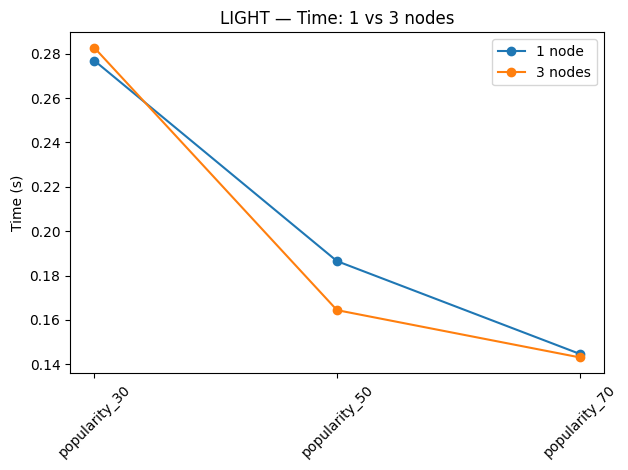

MEDIUM — Time: 1 vs 3 nodes
x=array([0, 1])
y1=[0.8308, 0.1827]
y2=[0.8581, 0.1906]


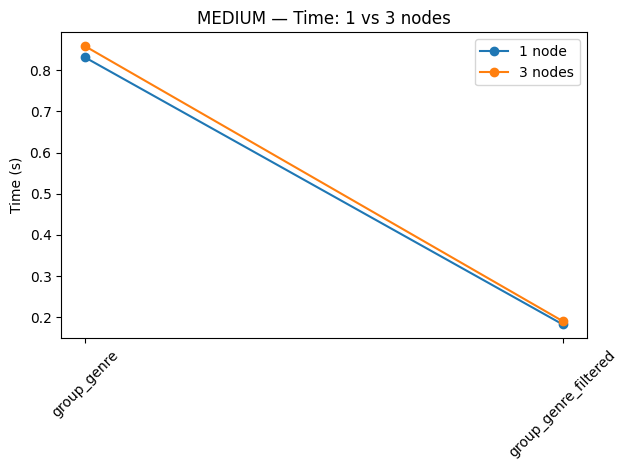

HEAVY — Time: 1 vs 3 nodes
x=array([0, 1, 2, 3])
y1=[2.6459, 2.2482, 2.0815, 0.1949]
y2=[2.77, 2.0523, 2.0736, 0.1833]


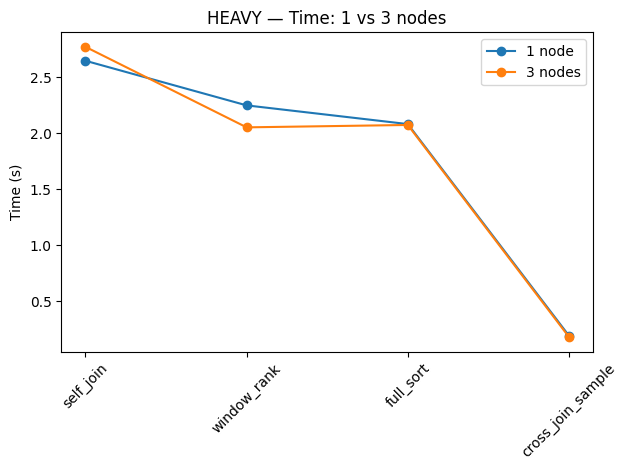

In [15]:
def extract_avg_time(run, level):
    stats = run["run_stats"][level]
    return {k: v["avg_time"] for k, v in stats.items()}

levels = ["light", "medium", "heavy"]

for level in levels:
    base_1 = extract_avg_time(runs["1_base"], level)
    base_3 = extract_avg_time(runs["3_base"], level)

    labels = list(base_1.keys())
    x = np.arange(len(labels))

    y1 = [base_1[k] for k in labels]
    y2 = [base_3[k] for k in labels]

    print(f"{level.upper()} — Time: 1 vs 3 nodes")
    print(f"{x=}")
    print(f"{y1=}")
    print(f"{y2=}")

    plt.figure()
    plt.title(f"{level.upper()} — Time: 1 vs 3 nodes")
    plt.xticks(x, labels, rotation=45)
    plt.plot(x, y1, marker='o', label="1 node")
    plt.plot(x, y2, marker='o', label="3 nodes")
    plt.ylabel("Time (s)")
    plt.legend()
    plt.tight_layout()
    plt.show()

Across all experiments, increasing the number of nodes and applying optimization does not consistently lead to proportional performance improvements, indicating that the benefits of distributed execution depend on workload complexity and are often limited by overhead.

## Speedup

LIGHT — Speedup (1 node / 3 nodes)
labels=['popularity_30', 'popularity_50', 'popularity_70']
speedup=[0.9794835514679872, 1.1344282238442822, 1.0111809923130677]


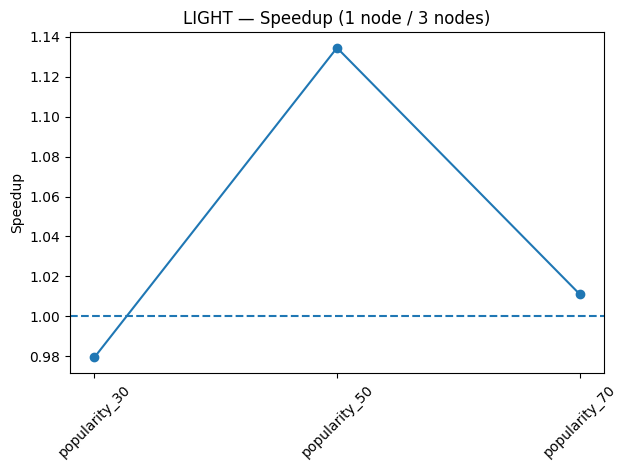

MEDIUM — Speedup (1 node / 3 nodes)
labels=['group_genre', 'group_genre_filtered']
speedup=[0.9681855261624519, 0.9585519412381952]


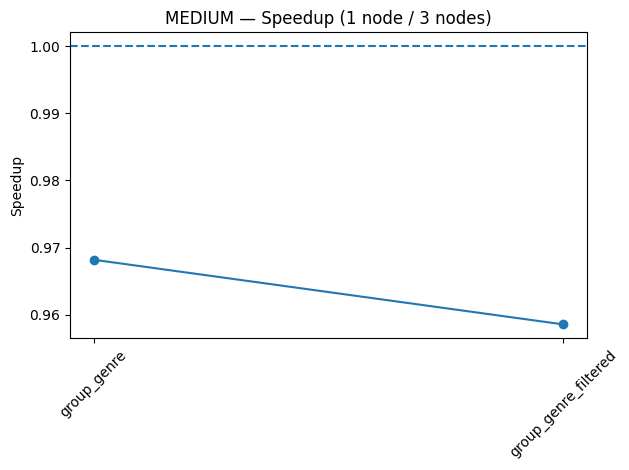

HEAVY — Speedup (1 node / 3 nodes)
labels=['self_join', 'window_rank', 'full_sort', 'cross_join_sample']
speedup=[0.9551985559566788, 1.0954538810115482, 1.0038097993827162, 1.0632842334969994]


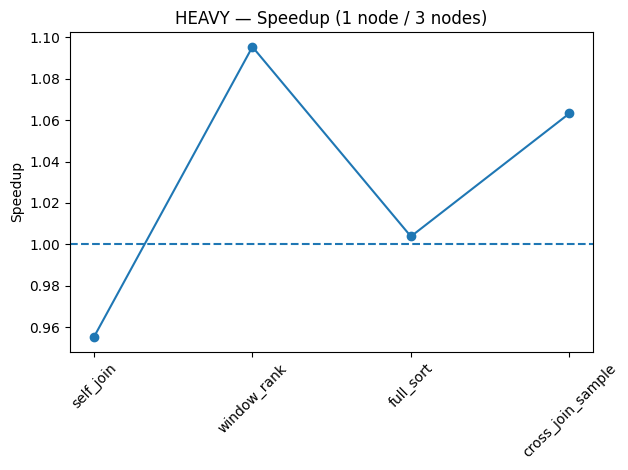

In [16]:
def extract_avg_time(run, level):
    stats = run["run_stats"][level]
    return {k: v["avg_time"] for k, v in stats.items()}

for level in levels:
    base_1 = extract_avg_time(runs["1_base"], level)
    base_3 = extract_avg_time(runs["3_base"], level)

    labels = list(base_1.keys())
    speedup = [base_1[k] / base_3[k] for k in labels]

    print(f"{level.upper()} — Speedup (1 node / 3 nodes)")
    print(f"{labels=}")
    print(f"{speedup=}")

    plt.figure()
    plt.title(f"{level.upper()} — Speedup (1 node / 3 nodes)")
    plt.xticks(range(len(labels)), labels, rotation=45)
    plt.plot(speedup, marker='o')
    plt.axhline(1, linestyle='--')
    plt.ylabel("Speedup")
    plt.tight_layout()
    plt.show()

Across all query types, the observed speedup between 1 and 3 nodes fluctuates around 1, indicating that distributed execution provides only marginal and inconsistent performance gains, with some cases showing slight slowdowns due to overhead and others showing modest improvements for more complex operations.

## Base vs Optimized (cache affection)

LIGHT — Base vs Optimized
labels=['popularity_30', 'popularity_50', 'popularity_70']
y1=[0.2769, 0.1865, 0.1447]
y2=[0.2265, 0.1332, 0.1189]


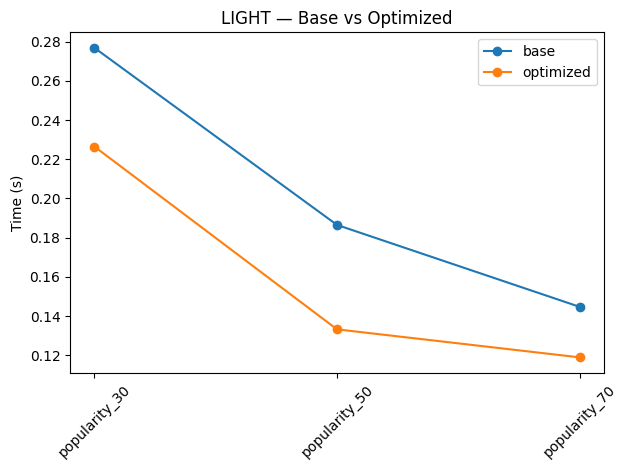

MEDIUM — Base vs Optimized
labels=['group_genre', 'group_genre_filtered']
y1=[0.8308, 0.1827]
y2=[0.8555, 0.2051]


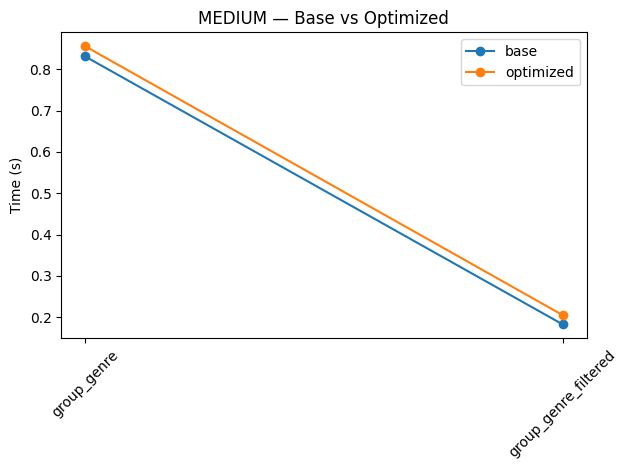

HEAVY — Base vs Optimized
labels=['self_join', 'window_rank', 'full_sort', 'cross_join_sample']
y1=[2.6459, 2.2482, 2.0815, 0.1949]
y2=[2.9287, 1.992, 1.9573, 0.2605]


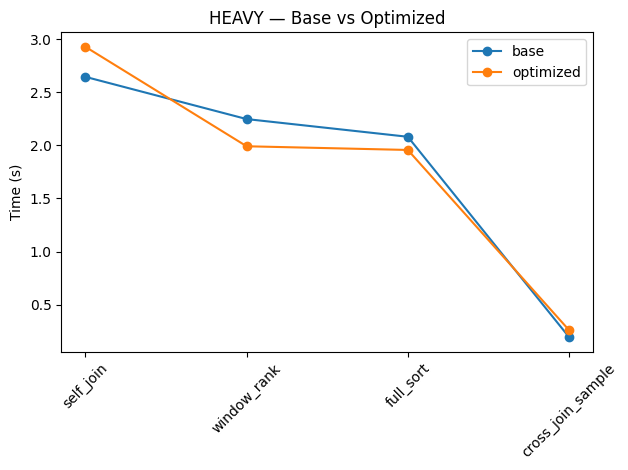

In [17]:
def extract_time(run, level):
    return {k: v["avg_time"] for k, v in run["run_stats"][level].items()}

for level in levels:
    base = extract_time(runs["1_base"], level)
    opt = extract_time(runs["1_opt"], level)

    labels = list(base.keys())
    x = np.arange(len(labels))

    y1 = [base[k] for k in labels]
    y2 = [opt[k] for k in labels]

    print(f"{level.upper()} — Base vs Optimized")
    print(f"{labels=}")
    print(f"{y1=}")
    print(f"{y2=}")

    plt.figure()
    plt.title(f"{level.upper()} — Base vs Optimized")
    plt.xticks(x, labels, rotation=45)
    plt.plot(x, y1, marker='o', label="base")
    plt.plot(x, y2, marker='o', label="optimized")
    plt.ylabel("Time (s)")
    plt.legend()
    plt.tight_layout()
    plt.show()

Across all query levels, optimization does not consistently improve performance: for light queries it provides noticeable speedups, while for medium and heavy queries the results are mixed, with some operations benefiting and others showing similar or even worse performance, indicating that the effect of optimization depends on the specific workload characteristics rather than providing a uniform improvement.

## Memory

LIGHT — Memory: Base vs Optimized
labels=['popularity_30', 'popularity_50', 'popularity_70']
y1=[4.95, 2.36, 1.75]
y2=[6.27, 1.87, 1.74]


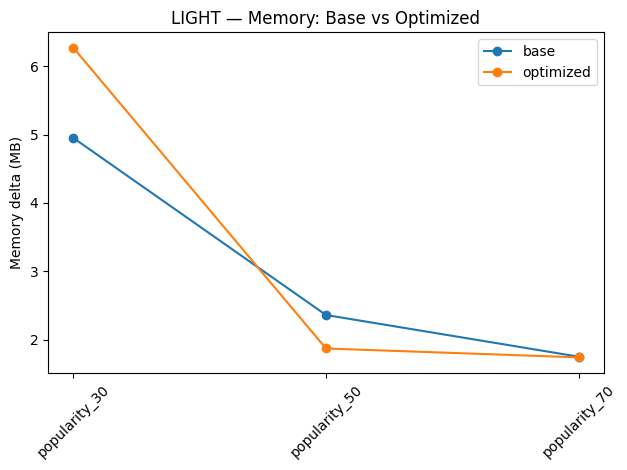

MEDIUM — Memory: Base vs Optimized
labels=['group_genre', 'group_genre_filtered']
y1=[6.46, 4.86]
y2=[8.8, 4.21]


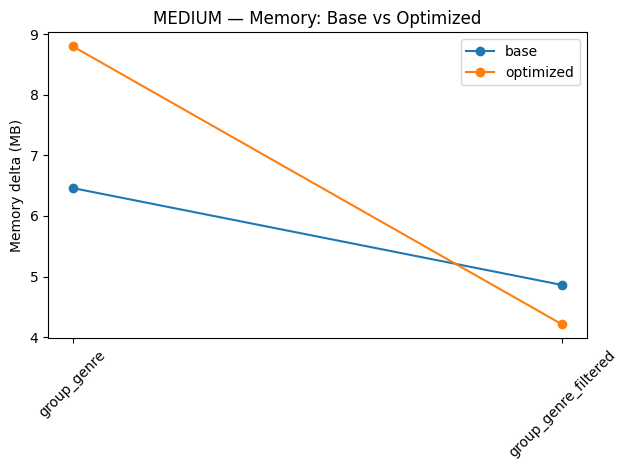

HEAVY — Memory: Base vs Optimized
labels=['self_join', 'window_rank', 'full_sort', 'cross_join_sample']
y1=[119.51, 54.64, 42.78, 3.89]
y2=[119.19, 52.96, 53.7, 3.47]


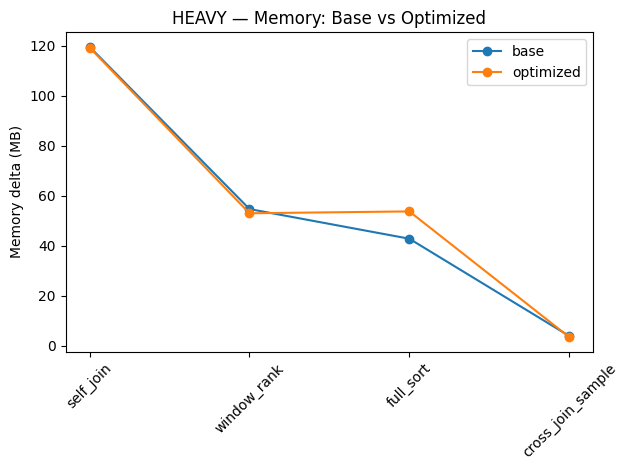

In [18]:
def extract_memory(run, level):
    stats = run["run_stats"][level]
    return {k: v["avg_delta_mb"] for k, v in stats.items()}

for level in levels:
    base = extract_memory(runs["1_base"], level)
    opt = extract_memory(runs["1_opt"], level)

    labels = list(base.keys())
    x = np.arange(len(labels))

    y1 = [base[k] for k in labels]
    y2 = [opt[k] for k in labels]

    print(f"{level.upper()} — Memory: Base vs Optimized")
    print(f"{labels=}")
    print(f"{y1=}")
    print(f"{y2=}")

    plt.figure()
    plt.title(f"{level.upper()} — Memory: Base vs Optimized")
    plt.xticks(x, labels, rotation=45)
    plt.plot(x, y1, marker='o', label="base")
    plt.plot(x, y2, marker='o', label="optimized")
    plt.ylabel("Memory delta (MB)")
    plt.legend()
    plt.tight_layout()
    plt.show()

Across all query types, the optimized version does not consistently reduce memory usage: for light and medium queries the differences are minor and mixed, while for heavy queries the memory consumption remains similar or even increases in some cases, indicating that optimization does not have a uniform effect on memory efficiency and may introduce additional overhead depending on the workload.

## Time vs Memory

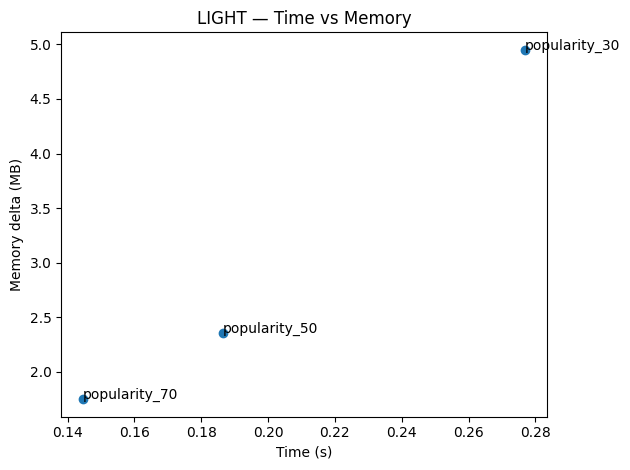

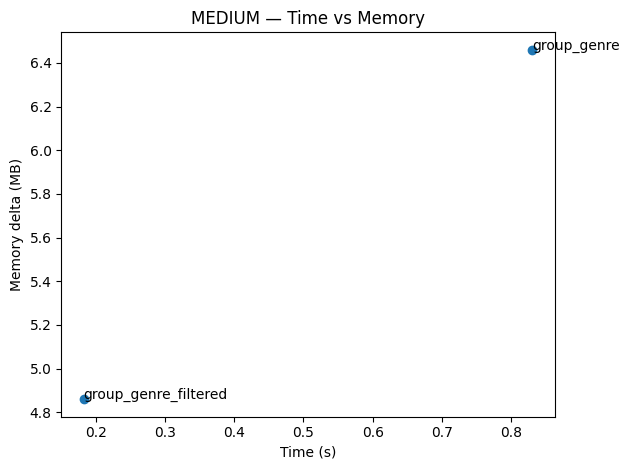

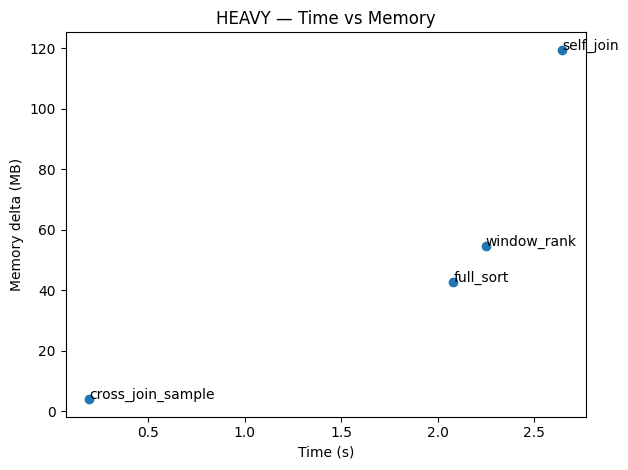

In [14]:
for level in levels:
    stats = runs["1_base"]["run_stats"][level]

    times = []
    memory = []

    for k, v in stats.items():
        times.append(v["avg_time"])
        memory.append(v["avg_delta_mb"])

    plt.figure()
    plt.title(f"{level.upper()} — Time vs Memory")

    plt.scatter(times, memory)

    for i, name in enumerate(stats.keys()):
        plt.text(times[i], memory[i], name)

    plt.xlabel("Time (s)")
    plt.ylabel("Memory delta (MB)")
    plt.tight_layout()
    plt.show()